# MIA EDA

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

In [ ]:
mia <- read.csv("MIA Appeals and Grievances.csv")

In [ ]:
admin <- read.csv('Admin Complaints.csv')

In [ ]:
str(mia)

'data.frame':   178 obs. of  95 variables:
 $ company.name                                                                 : chr  "4 Ever Life Insurance Company" "Aetna Dental, Inc." "Aetna Health Inc. ( a Pennsylvania corporation )" "Aetna Health Insurance Company" ...
 $ naic..                                                                       : int  80985 95910 95109 NA 60054 95163 61301 96202 47058 NA ...
 $ year                                                                         : int  2021 2021 2021 2021 2021 2021 2021 2021 2021 2021 ...
 $ adverse.decisions.company.total                                              : int  1 693 115 NA 188 NA 285 21128 7057 NA ...
 $ adverse.decisions.by.carrier.percent                                         : num  0 0.009 0.001 NA 0.002 NA 0.004 0.26 0.087 NA ...
 $ adverse.decisions.inpatient.hospital.services.number                         : int  1 0 39 NA 69 NA 0 12 2 NA ...
 $ adverse.decisions.inpatient.hospital.services.percent.tot

In [ ]:
names(mia) <- tolower(names(mia))
names(mia) <- gsub(' ',"_",names(mia))
names(mia) <- gsub("\\.", "_",names(mia))

In [ ]:
colnames(mia)

 [1] "company_name"                                                                 
 [2] "naic__"                                                                       
 [3] "year"                                                                         
 [4] "adverse_decisions_company_total"                                              
 [5] "adverse_decisions_by_carrier_percent"                                         
 [6] "adverse_decisions_inpatient_hospital_services_number"                         
 [7] "adverse_decisions_inpatient_hospital_services_percent_total"                  
 [8] "adverse_decisions_emergency_room_services_number"                             
 [9] "adverse_decisions_emergency_room_services_percent_total"                      
[10] "adverse_decisions_mental_health_services_number"                              
[11] "adverse_decisions_mental_health_services_percent_total"                       
[12] "adverse_decisions_physician_services_number"               

In [ ]:
colSums(is.na(mia))

                                                                 company_name 
                                                                            0 
                                                                       naic__ 
                                                                           44 
                                                                         year 
                                                                            0 
                                              adverse_decisions_company_total 
                                                                           25 
                                         adverse_decisions_by_carrier_percent 
                                                                           25 
                         adverse_decisions_inpatient_hospital_services_number 
                                                                           25 
                  adverse_decisions_inpatient_hospit

In [ ]:
summary(mia)

 company_name           naic__           year     
 Length:178         Min.   :21113   Min.   :2021  
 Class :character   1st Qu.:60321   1st Qu.:2021  
 Mode  :character   Median :68381   Median :2022  
                    Mean   :71058   Mean   :2022  
                    3rd Qu.:85766   3rd Qu.:2023  
                    Max.   :96940   Max.   :2024  
                    NA's   :44                    
 adverse_decisions_company_total adverse_decisions_by_carrier_percent
 Min.   :     1                  Min.   :0.00000                     
 1st Qu.:    27                  1st Qu.:0.00000                     
 Median :   286                  Median :0.00300                     
 Mean   :  5190                  Mean   :0.04993                     
 3rd Qu.:  1421                  3rd Qu.:0.01400                     
 Max.   :111426                  Max.   :1.00100                     
 NA's   :25                      NA's   :25                          
 adverse_decisions_inpatient_hos

In [ ]:
totals_only <- mia |>
  filter(company_name == "Total")

In [ ]:
str(admin)

'data.frame':   70 obs. of  12 variables:
 $ year                                                : int  2021 2021 2021 2021 2021 2021 2021 2021 2021 2021 ...
 $ Type.of.Procedure                                   : chr  "Air Ambulance" "Cosmetic" "Dental Care Services" "Durable Medical Equipment" ...
 $ carrier.code                                        : chr  "B" "D" "J" "I" ...
 $ total                                               : int  2 3 32 7 2 6 1 2 45 1 ...
 $ upheld.by.MIA.number                                : int  2 0 10 2 0 4 0 2 27 0 ...
 $ carrier.upheld.by.mia.percent                       : num  1 0 0.31 0.29 0 0.67 0 1 0.6 0 ...
 $ reversed.by.mia.number                              : int  0 2 4 3 0 1 1 0 11 0 ...
 $ carrier.reversed.by.mia.percent                     : num  0 0.67 0.13 0.43 0 0.17 1 0 0.24 0 ...
 $ modifed.by.mia.number                               : int  0 1 1 0 0 0 0 0 0 0 ...
 $ carrier.modifed.by.mia.percent                      : num  0 0.33 

In [ ]:
names(admin) <- tolower(names(admin))
names(admin) <- gsub(' ',"_",names(admin))
names(admin) <- gsub("\\.", "_",names(admin))

In [ ]:
admin_totals_only <- admin |>
  filter(type_of_procedure == "Total")

In [ ]:
colnames(admin)

 [1] "year"                                                
 [2] "type_of_procedure"                                   
 [3] "carrier_code"                                        
 [4] "total"                                               
 [5] "upheld_by_mia_number"                                
 [6] "carrier_upheld_by_mia_percent"                       
 [7] "reversed_by_mia_number"                              
 [8] "carrier_reversed_by_mia_percent"                     
 [9] "modifed_by_mia_number"                               
[10] "carrier_modifed_by_mia_percent"                      
[11] "carrier_reversed_itself_during_investigation_number" 
[12] "carrier_reversed_itself_during_investigation_percent"

In [ ]:
summary(admin)

      year      type_of_procedure  carrier_code           total       
 Min.   :2021   Length:70          Length:70          Min.   :  1.00  
 1st Qu.:2021   Class :character   Class :character   1st Qu.:  1.00  
 Median :2022   Mode  :character   Mode  :character   Median :  3.50  
 Mean   :2022                                         Mean   : 38.20  
 3rd Qu.:2023                                         3rd Qu.: 30.25  
 Max.   :2024                                         Max.   :395.00  
 upheld_by_mia_number carrier_upheld_by_mia_percent reversed_by_mia_number
 Min.   :  0.00       Min.   :0.0000                Min.   :  0.00        
 1st Qu.:  0.00       1st Qu.:0.0000                1st Qu.:  0.00        
 Median :  2.00       Median :0.2975                Median :  1.00        
 Mean   : 11.69       Mean   :0.3407                Mean   : 10.31        
 3rd Qu.:  9.75       3rd Qu.:0.5000                3rd Qu.:  4.00        
 Max.   :131.00       Max.   :1.0000                M

# Adverse Decisions

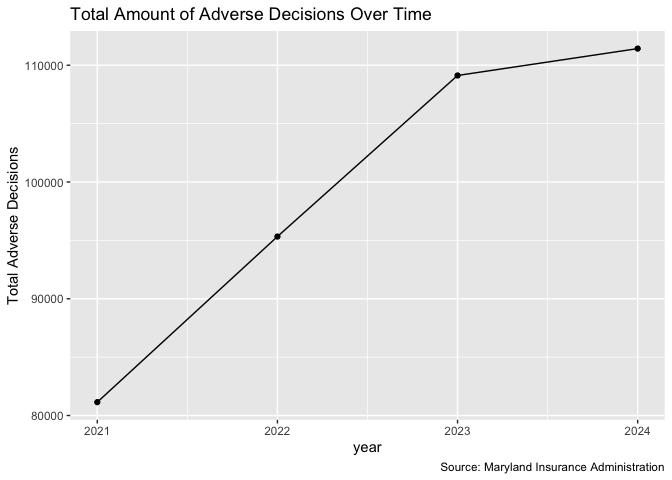

In [ ]:
adp1 <- totals_only |>
  select(year,adverse_decisions_company_total)|>
  ggplot(aes(x = year, y = adverse_decisions_company_total)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Total Amount of Adverse Decisions Over Time",
  caption = "Source: Maryland Insurance Administration",
  y = "Total Adverse Decisions")

adp1

In [ ]:
adverse_growth <- totals_only |>
  select(year,adverse_decisions_company_total) |>
  arrange(year)|>
  mutate(
    pct_change = (adverse_decisions_company_total - lag(adverse_decisions_company_total)) / lag(adverse_decisions_company_total) * 100
  )

adverse_growth

  year adverse_decisions_company_total pct_change
1 2021                           81143         NA
2 2022                           95327  17.480251
3 2023                          109123  14.472290
4 2024                          111426   2.110463

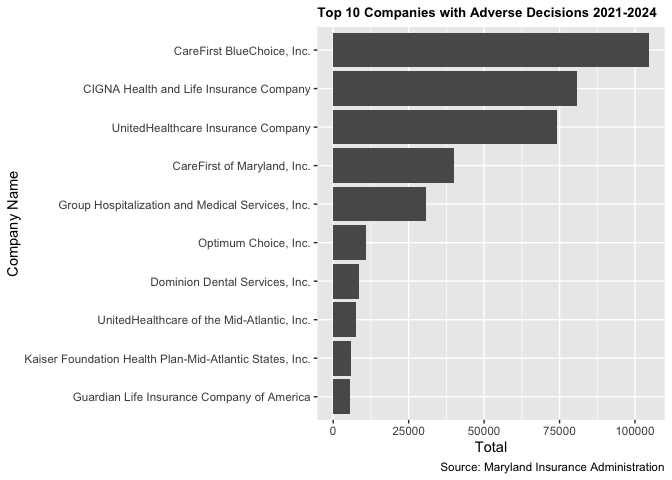

In [ ]:
top_companies_ad <- mia |>
  filter(`company_name` != "Total") |>
  group_by(`company_name`) |>
  summarise(total = sum(`adverse_decisions_company_total`, na.rm = TRUE)) |>
  arrange(desc(total)) |>
  head(10) |>
  ggplot(aes(x = reorder(`company_name`, total), y = total)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Top 10 Companies with Adverse Decisions 2021-2024",
    caption = 'Source: Maryland Insurance Administration',
    x = 'Company Name',
    y = 'Total'
  ) +
  theme(plot.title = element_text(size = 10, face = "bold"))

top_companies_ad

In [ ]:
totals_adverse_services <- totals_only |>
  select(
    year,
    adverse_decisions_inpatient_hospital_services_number,
    adverse_decisions_emergency_room_services_number,
    adverse_decisions_mental_health_services_number,
   adverse_decisions_physician_services_number,
  adverse_decisions_laboratory__radiology_services_number,
    adverse_decisions_pharmacy_services_number,
    adverse_decisions_pt__ot__st_services__incl_inpat_rehab__number_,
    adverse_decisions_skilled_nurse_faculty_sub_acute_nursing_home_number,
   adverse_decisions_durable_medical_equipment_services_number,
    adverse_decisions_dental_number,
    adverse_decisions_home_health_services_number,
    adverse_decisions_obesity__ivf__podiatry__hearing_and_vision_number_
  )

In [ ]:
totals_adverse_services_long <- totals_adverse_services |>
  pivot_longer(
    cols = -year,
    names_to = "service",
    values_to = "count"
  ) |>
  mutate(
    service = service |>
      str_remove("adverse_decisions") |>
      str_remove("_number_?$") |>
      str_replace_all("_", " ") |>
      str_to_title()
  )

In [ ]:
adverse_service_growth <- totals_adverse_services_long |>
  arrange(service, year) |>
  group_by(service) |>
  mutate(
    pct_change = (count - lag(count)) / lag(count) * 100
  ) |>
  ungroup() 


adverse_service_growth

# A tibble: 48 × 4
    year service                               count pct_change
   <int> <chr>                                 <int>      <dbl>
 1  2021 " Dental"                             15134     NA    
 2  2022 " Dental"                             15065     -0.456
 3  2023 " Dental"                             16732     11.1  
 4  2024 " Dental"                             16256     -2.84 
 5  2021 " Durable Medical Equipment Services"  1364     NA    
 6  2022 " Durable Medical Equipment Services"  1161    -14.9  
 7  2023 " Durable Medical Equipment Services"  1668     43.7  
 8  2024 " Durable Medical Equipment Services"  1554     -6.83 
 9  2021 " Emergency Room Services"               10     NA    
10  2022 " Emergency Room Services"              112   1020    
# ℹ 38 more rows

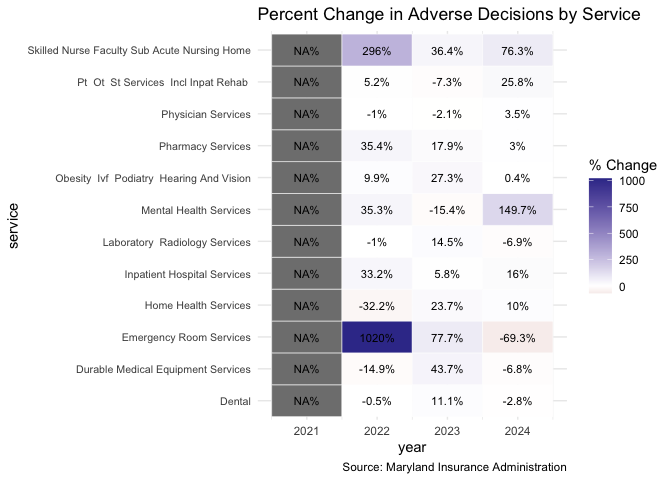

In [ ]:
ggplot(adverse_service_growth, aes(x = year, y = service, fill = pct_change)) +
  geom_tile(color = "white") +
  geom_text(aes(label = paste0(round(pct_change, 1), "%")), size = 3) +
  scale_fill_gradient2(
    name = "% Change"
  ) +
  labs(
    title = "Percent Change in Adverse Decisions by Service",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 8)
  )

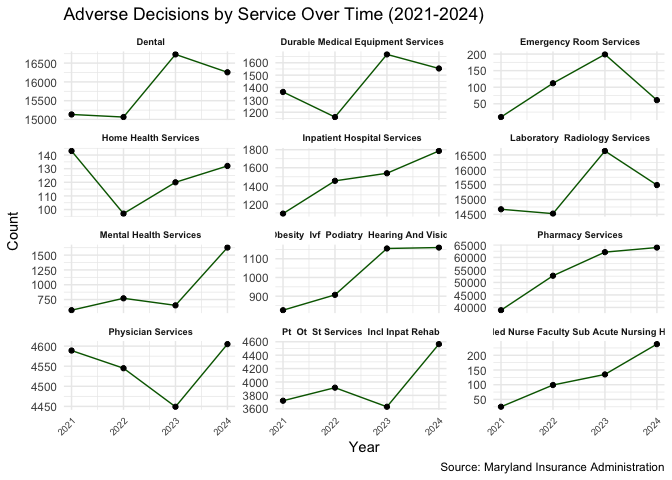

In [ ]:
ggplot(totals_adverse_services_long, aes(x = year, y = count)) +
  geom_line( color = "darkgreen") +
  geom_point() +
  facet_wrap(~ service, scales = "free_y", ncol = 3) +
  labs(
    title = "Adverse Decisions by Service Over Time (2021-2024)",
    x = "Year",
    y = "Count",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(
    strip.text = element_text(size = 7, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )

# Grievances

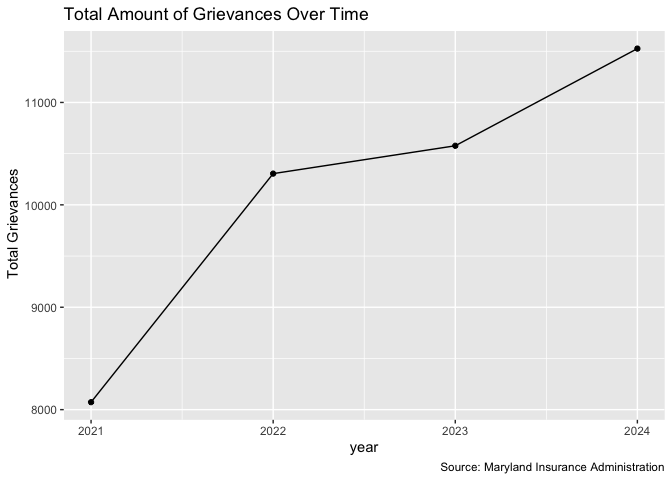

In [ ]:
grp1 <- totals_only |>
  select(year,grievances_filed_company_total)|>
  ggplot(aes(x = year, y = grievances_filed_company_total)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Total Amount of Grievances Over Time",
    caption = "Source: Maryland Insurance Administration",
    y = " Total Grievances"
  )
grp1

In [ ]:
grievance_growth <- totals_only |>
  select(year,grievances_filed_company_total) |>
  arrange(year) |>
  mutate(
    pct_change = (grievances_filed_company_total - lag(grievances_filed_company_total)) / lag(grievances_filed_company_total) * 100
  )

grievance_growth

  year grievances_filed_company_total pct_change
1 2021                           8073         NA
2 2022                          10305  27.647715
3 2023                          10577   2.639495
4 2024                          11526   8.972298

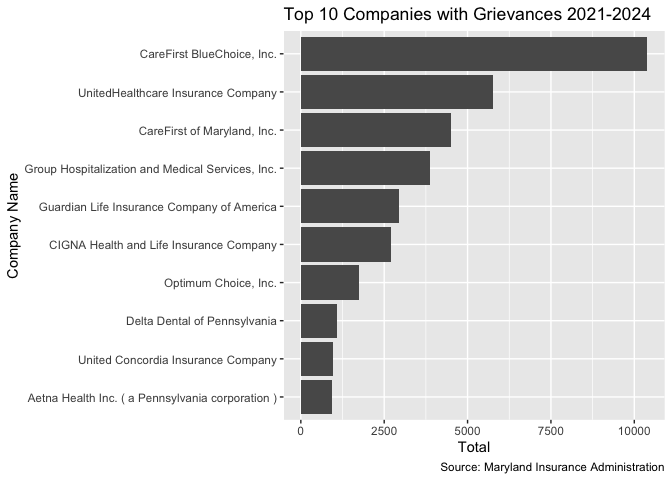

In [ ]:
top_companies_gr <- mia |>
  filter(`company_name` != "Total") |>
  group_by(`company_name`) |>
  summarise(total = sum(`grievances_filed_company_total`, na.rm = TRUE)) |>
  arrange(desc(total)) |>
  head(10) |>
  ggplot(aes(x = reorder(`company_name`, total), y = total)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Top 10 Companies with Grievances 2021-2024",
       x = 'Company Name',
       y= 'Total',
       caption = "Source: Maryland Insurance Administration"
       ) 
top_companies_gr

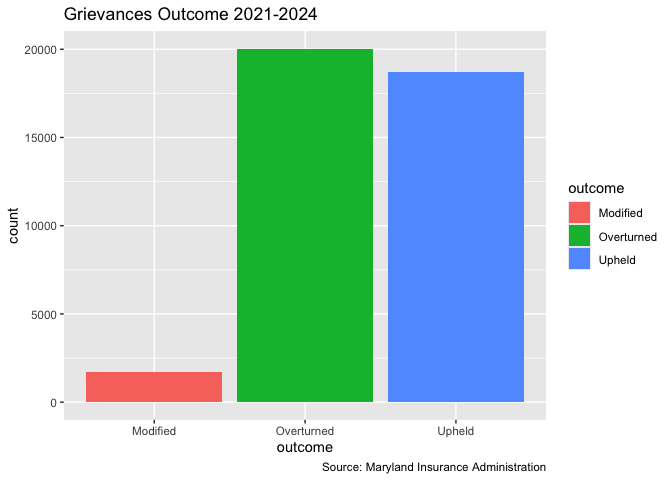

In [ ]:
outcome <- totals_only |>
select(grievances_upheld_number,grievances_overturned_number,grievances_modified_number)|>
  pivot_longer(everything(), names_to = "outcome", values_to = "count") |>
mutate(outcome = outcome |>
      str_remove("grievances_") |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
)|>
  ggplot(aes(x = outcome, y = count, fill = outcome)) +
  geom_bar(stat = "identity") +
labs(
  title = "Grievances Outcome 2021-2024",
  caption = "Source: Maryland Insurance Administration"
)
outcome

In [ ]:
totals_grievances_services <- totals_only |>
  select(
    year,
    grievance_inpatient_hospital_services_number,
    grievance_emergency_room_services_number,
    grievance_mental_health_services_number,
    grievance_physician_services_number,
    grievance_laboratory__radiology_services_number,
    grievance_pharmacy_services_number,
    grievance_pt__ot__st_services__incl_inpat_rehab__number_,
    grievance_skilled_nurse_faculty_sub_acute_nursing_home_number,
    grievance_durable_medical_equipment_services_number,
    grievance_dental_number,
    grievance_home_health_services_number,
    grievance_obesity__ivf__podiatry__hearing_and_vision_number_
  )

In [ ]:
totals_grievances_services_long <- totals_grievances_services |>
  pivot_longer(
    cols = -year,
    names_to = "service",
    values_to = "count"
  ) |>
  mutate(
    service = service |>
      str_remove("grievance") |>
      str_remove("_number_?$") |>
      str_replace_all("_", " ") |>
      str_to_title()
  )

In [ ]:
grievance_service_growth <- totals_grievances_services_long |>
  arrange(service, year) |>
  group_by(service) |>
  mutate(
    pct_change = (count - lag(count)) / lag(count) * 100
  ) |>
  ungroup() |>
    mutate(
    service = service |>
      str_remove("grievance") |>
      str_remove("_number_?$") |>
      str_replace_all("_", " ") |>
      str_to_title() 
    )

grievance_service_growth

# A tibble: 48 × 4
    year service                               count pct_change
   <int> <chr>                                 <int>      <dbl>
 1  2021 " Dental"                              2375      NA   
 2  2022 " Dental"                              3169      33.4 
 3  2023 " Dental"                              2160     -31.8 
 4  2024 " Dental"                              1937     -10.3 
 5  2021 " Durable Medical Equipment Services"   123      NA   
 6  2022 " Durable Medical Equipment Services"   216      75.6 
 7  2023 " Durable Medical Equipment Services"   196      -9.26
 8  2024 " Durable Medical Equipment Services"   376      91.8 
 9  2021 " Emergency Room Services"               20      NA   
10  2022 " Emergency Room Services"               30      50   
# ℹ 38 more rows

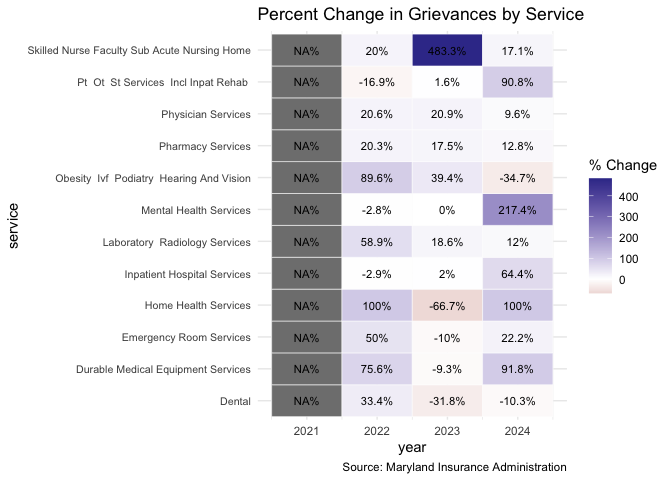

In [ ]:
ggplot(grievance_service_growth, aes(x = year, y = service, fill = pct_change)) +
  geom_tile(color = "white") +
  geom_text(aes(label = paste0(round(pct_change, 1), "%")), size = 3) +
  scale_fill_gradient2(
    name = "% Change"
  ) +
  labs(
    title = "Percent Change in Grievances by Service",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 8)
  )

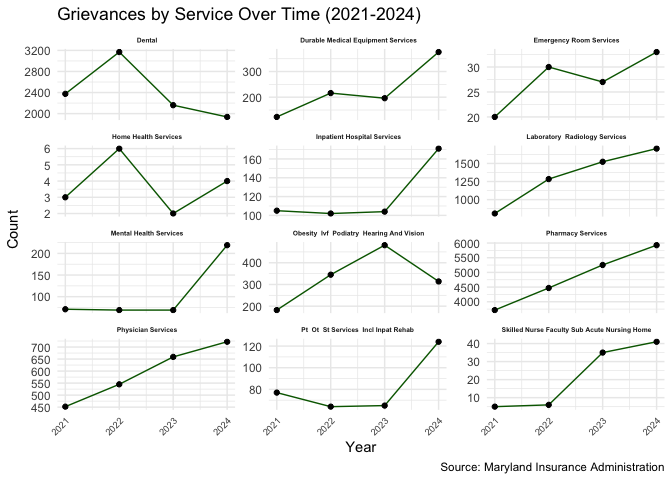

In [ ]:
ggplot(totals_grievances_services_long, aes(x = year, y = count)) +
  geom_line( color = "darkgreen") +
  geom_point() +
  facet_wrap(~ service, scales = "free_y", ncol = 3) +
  labs(
    title = "Grievances by Service Over Time (2021-2024)",
    x = "Year",
    y = "Count",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(
    strip.text = element_text(size = 5, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )

ℹ Please use `linewidth` instead.

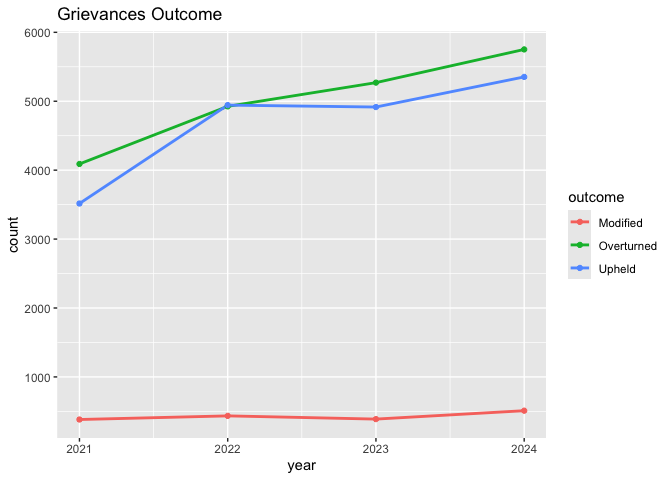

In [ ]:
gr_outcome <- totals_only|>
select(year,grievances_overturned_number,grievances_upheld_number,grievances_modified_number)|>
   group_by(year) |>
  pivot_longer(-year, names_to = "outcome", values_to = "count") |>
  mutate(
    outcome = outcome |>
      str_remove("grievances_") |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
  ) |>
  ggplot(aes(x = year, y = count, color = outcome)) +
  geom_line(size = 1) +
  geom_point()+
  labs(
    title = "Grievances Outcome"
  )

# Hospital Length Of Stay

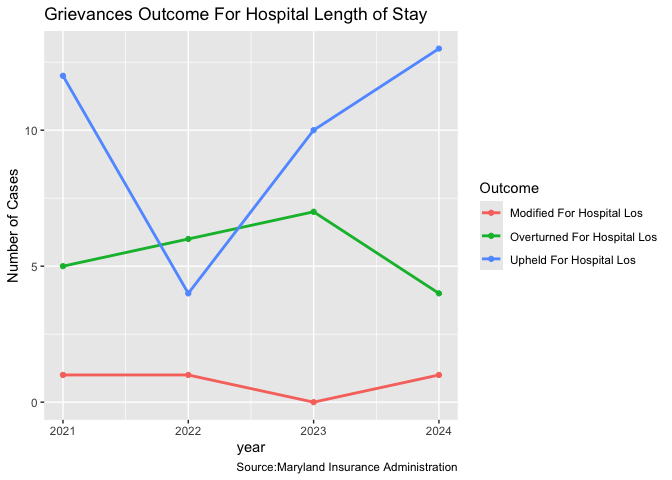

In [ ]:
mia_los<- totals_only |>
select(year,grievances_upheld_number_for_hospital_los,grievances_overturned_number_for_hospital_los,grievances_modified_number_for_hospital_los)|>  group_by(year) |>
  pivot_longer(-year, names_to = "outcome", values_to = "count") |>
  mutate(
    outcome = outcome |>
      str_remove("grievances_") |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
  ) |>
  ggplot(aes(x = year, y = count, color = outcome)) +
  geom_line(size = 1) +
  geom_point() +
  labs(
    title = "Grievances Outcome For Hospital Length of Stay",
    y = "Number of Cases",
    color = "Outcome",
    caption = "Source:Maryland Insurance Administration"
  )
mia_los

# Emergency Cases Resolution Hours

In [ ]:
emer_res <- totals_only|>
  select(year, emergency_cases___resolution_hours_1_st_quarter_,emergency_cases___resolution_hours_2nd_quarter_,emergency_cases___resolution_hours_3rd__quarter_,emergency_cases___resolution_hours_4th_quarter_) 

In [ ]:
emer_res_long <- emer_res |>
  pivot_longer(
    cols = -year,
    names_to = "quarters",
    values_to = "resolution_hours"
  )|>
  mutate(
    quarters = quarters |>
      str_remove("emergency_cases___resolution_hours_") |>
      str_replace_all("_", " ") |>
      str_to_title()
  )

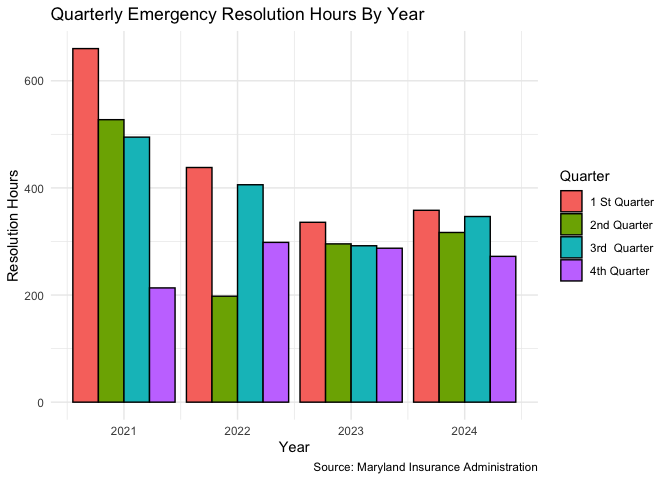

In [ ]:
ggplot(emer_res_long, aes(x = year, y = resolution_hours, fill = quarters)) +
  geom_bar(stat = "identity", color = "black",
           position = position_dodge(width = 0.9)) +
  labs(
    title = "Quarterly Emergency Resolution Hours By Year",
    x = "Year",
    y = "Resolution Hours",
    fill = "Quarter",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal()

# Non-Emergency Cases Resolution Days

In [ ]:
non_emer_res <- totals_only|>
  select(year, non_emergency_cases___resolution_days_1st_quarter,non_emergency_cases___resolution_days_2nd_quarter,non_emergency_cases___resolution_days_3rd_quarter,non_emergency_cases___resolution_days_4th_quarter) 

In [ ]:
non_emer_res_long <- non_emer_res |>
  pivot_longer(
    cols = -year,
    names_to = "quarters",
    values_to = "resolution_days"
  )|>
  mutate(
    quarters = quarters |>
      str_remove("non_emergency_cases___resolution_days_") |>
      str_replace_all("_", " ") |>
      str_to_title()
  )

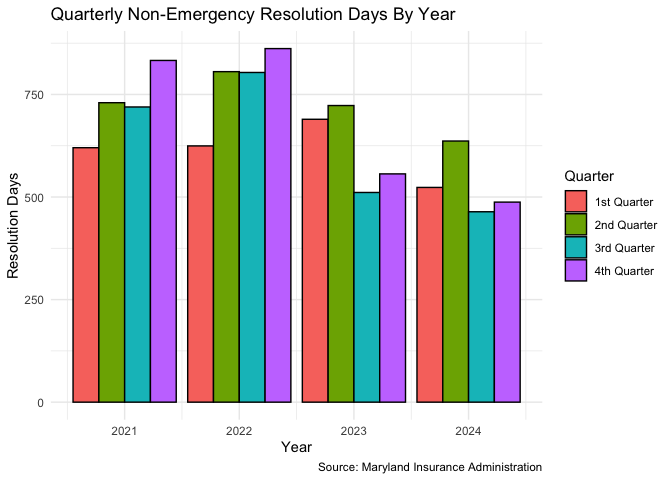

In [ ]:
ggplot(non_emer_res_long, aes(x = year, y = resolution_days, fill = quarters)) +
  geom_bar(stat = "identity", color = "black",
           position = position_dodge(width = 0.9)) +
  labs(
    title = "Quarterly Non-Emergency Resolution Days By Year",
    x = "Year",
    y = "Resolution Days",
    fill = "Quarter",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal()

# MIA Outcome

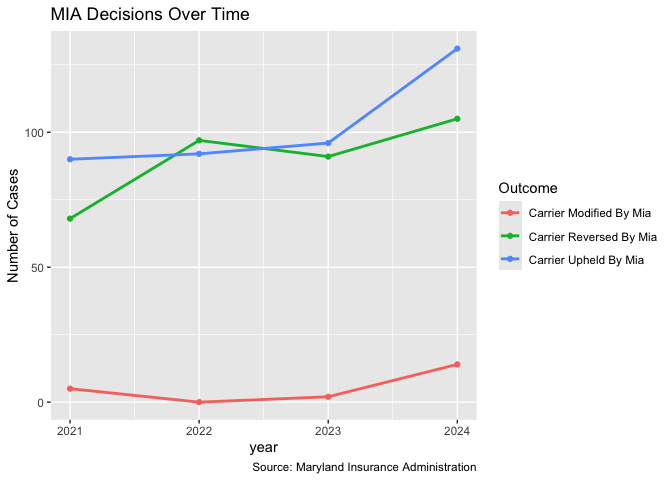

In [ ]:
mia_dec<- totals_only |>
  select(year,carrier_upheld_by_mia_number,carrier_modified_by_mia_number,carrier_reversed_by_mia_number)|>
  pivot_longer(-year, names_to = "outcome", values_to = "count") |>
  mutate(
    outcome = outcome |>
      str_remove("grievances_") |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
  ) |>
  ggplot(aes(x = year, y = count, color = outcome)) +
  geom_line(size = 1) +
  geom_point() +
  labs(
    title = "MIA Decisions Over Time",
    y = "Number of Cases",
    color = "Outcome",
    caption = "Source: Maryland Insurance Administration"
  )
mia_dec

In [ ]:
admin_clean <- admin |>
  filter(type_of_procedure != "TOTAL") |>
  pivot_longer(
    cols = c(
      upheld_by_mia_number,
      reversed_by_mia_number,
      modifed_by_mia_number,
      carrier_reversed_itself_during_investigation_number
    ),
    names_to = "outcome",
    values_to = "count"
  ) |>
  mutate(
    outcome = outcome |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
  ) |>
  group_by(type_of_procedure) |>
  filter(sum(count, na.rm = TRUE) >= 10) |> 
  ungroup()

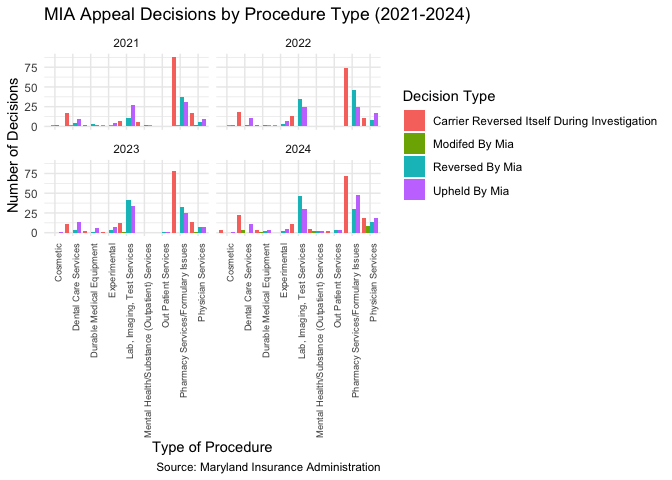

In [ ]:
ggplot(admin_clean,aes(x = type_of_procedure, y = count, fill = outcome)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  facet_wrap(~ year, ncol = 2) +
  labs(
    title = "MIA Appeal Decisions by Procedure Type (2021-2024)",
    x = "Type of Procedure",
    y = "Number of Decisions",
    fill = "Decision Type",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 7))